# Robustness Check — Apakah Perbandingan Model 1 vs 2 vs 3 Stabil?
## Repeated Random Train/Test Split (200x)

Perbandingan Model 1, 2, dan 3 sebelumnya cuma pakai **satu kali** split random 80/20
(`random_state=42`). Notebook ini menguji seberapa stabil kesimpulan itu dengan mengulang
proses split-fit-evaluate sebanyak **200 kali** dengan seed berbeda-beda, lalu melihat:

1. Seberapa besar variasi (noise) hit rate hold-out antar split
2. Apakah AIC Model 3 konsisten lebih rendah dari Model 2 di sebagian besar split
3. Apakah variabel kunci (`Income_x_Bisnis`, `HargaDiff`) konsisten signifikan
4. Sebagai pembanding, hasil dari **k-fold cross-validation** (pemakaian data lebih efisien
   dibanding repeated split)

**Catatan:** sel-sel di notebook ini belum dijalankan (`Run All` dulu sebelum dibaca) — 200
repetisi x 3 model harusnya selesai dalam hitungan detik-menit tergantung mesin, bukan
proses berat.


In [11]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import train_test_split, StratifiedKFold
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

np.random.seed(0)


## 1. Load Data & Definisi 3 Model

In [12]:
df = pd.read_csv('Data_Binary_Logit_Pullman-vs-Novotel.csv')

df['y'] = (df['BrandPilihan'] == 'Pullman').astype(int)
df['Bisnis'] = (df['TujuanMenginap'] == 'Bisnis').astype(int)
df['Income_x_Bisnis'] = df['Income_JutaRp'] * df['Bisnis']
df['HargaDiff'] = df['Harga_Pullman'] - df['Harga_Novotel']

cols_m1 = ['Bisnis', 'Income_JutaRp', 'Harga_Novotel', 'Harga_Pullman', 'Iklan_Novotel', 'Iklan_Pullman']
cols_m2 = cols_m1 + ['Income_x_Bisnis']
cols_m3 = ['Bisnis', 'Income_JutaRp', 'HargaDiff', 'Iklan_Novotel', 'Iklan_Pullman', 'Income_x_Bisnis']

MODEL_SPECS = {
    'Model 1 (sederhana)': cols_m1,
    'Model 2 (+interaksi)': cols_m2,
    'Model 3 (+HargaDiff)': cols_m3,
}

y = df['y']
df.head()


,RespID,TujuanMenginap,Income_JutaRp,Harga_Novotel,Harga_Pullman,Iklan_Novotel,Iklan_Pullman,BrandPilihan,y,Bisnis,Income_x_Bisnis,HargaDiff
0,1,Bisnis,16.7,738000,1207000,0,0,Novotel,0,1,16.7,469000
1,2,Bisnis,11.2,626000,1615000,0,1,Pullman,1,1,11.2,989000
2,3,Leisure/Pribadi,20.6,911000,1301000,0,0,Novotel,0,0,0.0,390000
3,4,Bisnis,3.0,914000,1204000,0,0,Pullman,1,1,3.0,290000
4,5,Leisure/Pribadi,17.3,1100000,1837000,1,1,Novotel,0,0,0.0,737000


## 2. Fungsi Bantuan: Fit Satu Model di Satu Split

In [13]:
def fit_and_evaluate(cols, idx_train, idx_test, y):
    X_train = sm.add_constant(df.loc[idx_train, cols])
    X_test = sm.add_constant(df.loc[idx_test, cols], has_constant='add')[X_train.columns]
    y_train, y_test = y.loc[idx_train], y.loc[idx_test]

    model = sm.Logit(y_train, X_train).fit(disp=0)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    hit_train = ((pred_train >= 0.5).astype(int) == y_train).mean()
    hit_test = ((pred_test >= 0.5).astype(int) == y_test).mean()

    return {
        'aic': model.aic,
        'bic': model.bic,
        'llf': model.llf,
        'prsquared': model.prsquared,
        'hit_train': hit_train,
        'hit_test': hit_test,
        'pvalues': model.pvalues.to_dict(),
    }


## 3. Repeated Random Split (200x)

Untuk tiap seed (0 sampai 199): split data 80/20 (stratified), fit ketiga model di data
training yang sama, evaluasi di data testing yang sama, simpan semua metrik.


In [14]:
N_REPEATS = 200
records = []

for seed in range(N_REPEATS):
    idx_train, idx_test = train_test_split(df.index, test_size=0.2, random_state=seed, stratify=y)
    for model_name, cols in MODEL_SPECS.items():
        result = fit_and_evaluate(cols, idx_train, idx_test, y)
        records.append({
            'seed': seed,
            'model': model_name,
            'aic': result['aic'],
            'bic': result['bic'],
            'prsquared': result['prsquared'],
            'hit_train': result['hit_train'],
            'hit_test': result['hit_test'],
            'p_income_x_bisnis': result['pvalues'].get('Income_x_Bisnis', np.nan),
            'p_hargadiff': result['pvalues'].get('HargaDiff', np.nan),
        })

results_df = pd.DataFrame(records)
print(f'Selesai: {N_REPEATS} repetisi x {len(MODEL_SPECS)} model = {len(results_df)} baris hasil')
results_df.head(9)


Selesai: 200 repetisi x 3 model = 600 baris hasil


,seed,model,aic,bic,prsquared,hit_train,hit_test,p_income_x_bisnis,p_hargadiff
0,0,Model 1 (sederhana),428.239234,456.179486,0.252853,0.7575,0.71,NaN,NaN
1,0,Model 2 (+interaksi),362.266257,394.197973,0.375453,0.7925,0.78,7.513234e-11,NaN
2,0,Model 3 (+HargaDiff),360.446542,388.386794,0.375128,0.7925,0.78,7.757680e-11,0.006012
3,1,Model 1 (sederhana),442.251332,470.191584,0.227580,0.7350,0.71,NaN,NaN
4,1,Model 2 (+interaksi),374.474110,406.405827,0.353434,0.7775,0.81,2.570995e-11,NaN
5,1,Model 3 (+HargaDiff),373.353175,401.293427,0.351848,0.7700,0.82,2.778222e-11,0.000843
6,2,Model 1 (sederhana),445.676965,473.617217,0.221401,0.7325,0.77,NaN,NaN
7,2,Model 2 (+interaksi),371.366524,403.298241,0.359039,0.7950,0.82,1.489918e-11,NaN
8,2,Model 3 (+HargaDiff),369.439539,397.379791,0.358907,0.7925,0.82,1.337677e-11,0.001353


## 4. Ringkasan: Rata-Rata & Variasi Tiap Model Sepanjang 200 Split

In [15]:
summary = results_df.groupby('model').agg(
    AIC_mean=('aic', 'mean'), AIC_std=('aic', 'std'),
    McFaddenR2_mean=('prsquared', 'mean'),
    HitTrain_mean=('hit_train', 'mean'), HitTrain_std=('hit_train', 'std'),
    HitTest_mean=('hit_test', 'mean'), HitTest_std=('hit_test', 'std'),
    HitTest_min=('hit_test', 'min'), HitTest_max=('hit_test', 'max'),
).round(4)
summary


,AIC_mean,AIC_std,McFaddenR2_mean,HitTrain_mean,HitTrain_std,HitTest_mean,HitTest_std,HitTest_min,HitTest_max
model,,,,,,,,,
Model 1 (sederhana),432.6719,9.2880,0.2449,0.7497,0.0127,0.7339,0.0396,0.6,0.83
Model 2 (+interaksi),367.6696,9.5980,0.3657,0.7945,0.0099,0.7884,0.0358,0.7,0.89
Model 3 (+HargaDiff),366.2787,9.6134,0.3646,0.7932,0.0096,0.7875,0.0350,0.7,0.87


## 5. Visualisasi Sebaran Hit Rate Hold-Out Antar 200 Split

Boxplot ini menunjukkan seberapa lebar variasi hit rate hold-out untuk tiap model — kalau
kotak/whisker-nya lebar, artinya satu kali angka hasil split tunggal cukup berisiko meleset
dari rata-rata sesungguhnya.


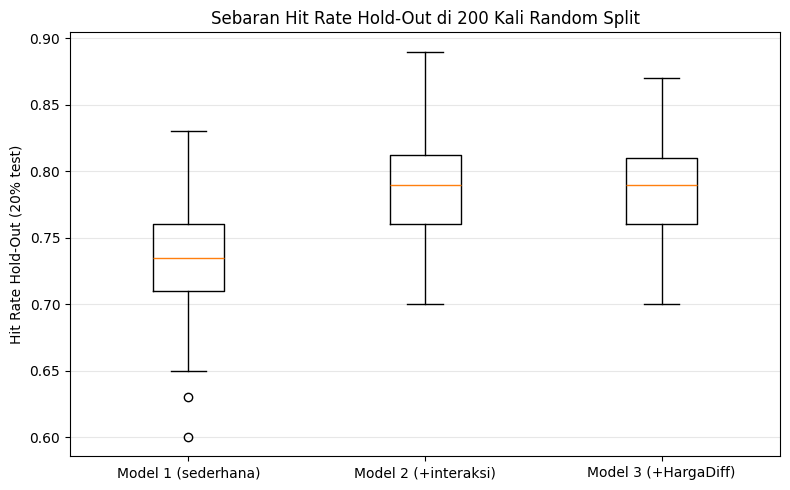

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))
data_to_plot = [results_df[results_df['model'] == m]['hit_test'].values for m in MODEL_SPECS.keys()]
ax.boxplot(data_to_plot, labels=list(MODEL_SPECS.keys()))
ax.set_ylabel('Hit Rate Hold-Out (20% test)')
ax.set_title(f'Sebaran Hit Rate Hold-Out di {N_REPEATS} Kali Random Split')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


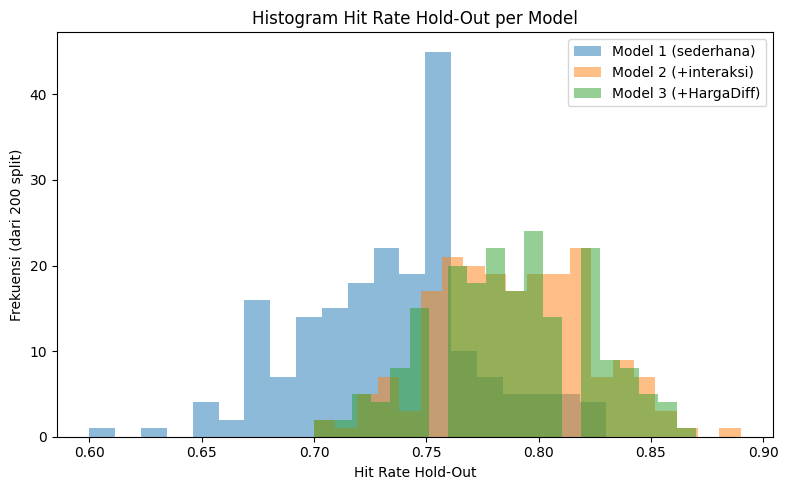

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
for m in MODEL_SPECS.keys():
    ax.hist(results_df[results_df['model'] == m]['hit_test'], bins=20, alpha=0.5, label=m)
ax.set_xlabel('Hit Rate Hold-Out')
ax.set_ylabel('Frekuensi (dari 200 split)')
ax.set_title('Histogram Hit Rate Hold-Out per Model')
ax.legend()
plt.tight_layout()
plt.show()


## 6. Seberapa Sering Model 3 Menang Melawan Model 2 (by AIC)?

In [18]:
pivot_aic = results_df.pivot(index='seed', columns='model', values='aic')
m3_wins = (pivot_aic['Model 3 (+HargaDiff)'] < pivot_aic['Model 2 (+interaksi)']).mean()
print(f"Model 3 AIC lebih rendah dari Model 2 di {m3_wins*100:.1f}% dari {N_REPEATS} split")

pivot_hit = results_df.pivot(index='seed', columns='model', values='hit_test')
m3_hit_wins = (pivot_hit['Model 3 (+HargaDiff)'] >= pivot_hit['Model 2 (+interaksi)']).mean()
print(f"Model 3 hit rate hold-out >= Model 2 di {m3_hit_wins*100:.1f}% dari {N_REPEATS} split")

m2_vs_m1 = (pivot_hit['Model 2 (+interaksi)'] > pivot_hit['Model 1 (sederhana)']).mean()
print(f"Model 2 hit rate hold-out > Model 1 di {m2_vs_m1*100:.1f}% dari {N_REPEATS} split")


Model 3 AIC lebih rendah dari Model 2 di 97.0% dari 200 split
Model 3 hit rate hold-out >= Model 2 di 72.0% dari 200 split
Model 2 hit rate hold-out > Model 1 di 96.5% dari 200 split


## 7. Stabilitas Signifikansi Variabel Kunci

Income_x_Bisnis signifikan (p<0.05) di 100.0% dari 200 split (Model 2)
HargaDiff signifikan (p<0.05) di 99.5% dari 200 split (Model 3)


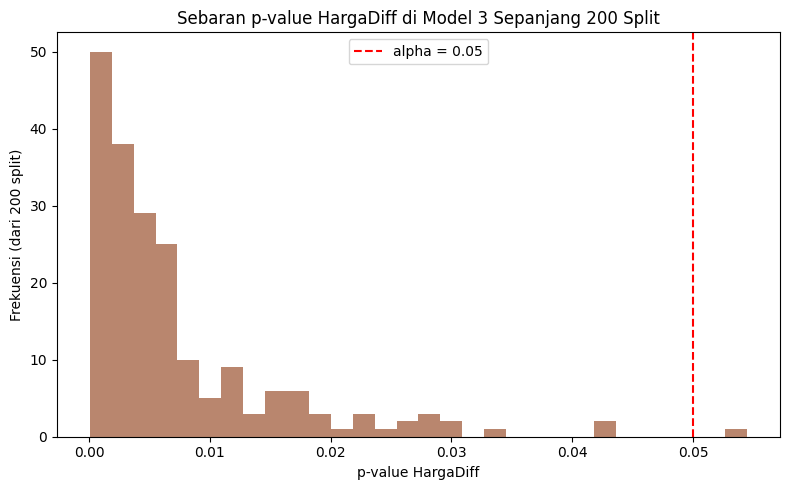

In [19]:
interaction_sig_rate = (results_df[results_df['model'] == 'Model 2 (+interaksi)']['p_income_x_bisnis'] < 0.05).mean()
hargadiff_sig_rate = (results_df[results_df['model'] == 'Model 3 (+HargaDiff)']['p_hargadiff'] < 0.05).mean()

print(f"Income_x_Bisnis signifikan (p<0.05) di {interaction_sig_rate*100:.1f}% dari {N_REPEATS} split (Model 2)")
print(f"HargaDiff signifikan (p<0.05) di {hargadiff_sig_rate*100:.1f}% dari {N_REPEATS} split (Model 3)")

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(results_df[results_df['model']=='Model 3 (+HargaDiff)']['p_hargadiff'], bins=30, color='#9C5330', alpha=0.7)
ax.axvline(0.05, color='red', linestyle='--', label='alpha = 0.05')
ax.set_xlabel('p-value HargaDiff')
ax.set_ylabel('Frekuensi (dari 200 split)')
ax.set_title('Sebaran p-value HargaDiff di Model 3 Sepanjang 200 Split')
ax.legend()
plt.tight_layout()
plt.show()


## 8. Pembanding: K-Fold Cross-Validation (Lebih Efisien Memakai Data)

Repeated random split di atas boros: tiap kali cuma pakai 80% data buat training dan 20%
dibuang untuk testing, lalu diulang-ulang dengan overlap antar split. **K-Fold CV** membagi
data jadi K bagian; tiap bagian gantian jadi test set persis sekali, sehingga tiap baris
data dipakai baik untuk training maupun testing tanpa membuang data ekstra. Ini pembanding
yang lebih standar di komunitas machine learning/statistik untuk mengukur performa
out-of-sample yang stabil.


In [20]:
K = 10
skf = StratifiedKFold(n_splits=K, shuffle=True, random_state=42)

cv_records = []
for model_name, cols in MODEL_SPECS.items():
    fold_hits = []
    for fold_i, (idx_train, idx_test) in enumerate(skf.split(df, y)):
        idx_train = df.index[idx_train]
        idx_test = df.index[idx_test]
        result = fit_and_evaluate(cols, idx_train, idx_test, y)
        fold_hits.append(result['hit_test'])
    cv_records.append({
        'model': model_name,
        f'{K}-Fold Hit Rate (mean)': np.mean(fold_hits),
        f'{K}-Fold Hit Rate (std)': np.std(fold_hits),
    })

cv_summary = pd.DataFrame(cv_records)
cv_summary.round(4)


,model,10-Fold Hit Rate (mean),10-Fold Hit Rate (std)
0,Model 1 (sederhana),0.726,0.0498
1,Model 2 (+interaksi),0.792,0.0483
2,Model 3 (+HargaDiff),0.792,0.0483


## 9. Kesimpulan Robustness Check

Isi ringkasan ini otomatis mengikuti angka-angka yang dihitung di atas — baca hasil run kamu
di sel-sel sebelumnya untuk menyimpulkan:

- Apakah urutan Model 1 < Model 2 ≈ Model 3 (dari sisi hit rate) konsisten di hampir semua split?
- Apakah Income_x_Bisnis dan HargaDiff tetap signifikan di mayoritas split (>90%)?
- Apakah Model 3 tetap unggul AIC dibanding Model 2 di mayoritas split?
- Apakah hasil K-Fold CV (poin 8) sejalan dengan rata-rata repeated split (poin 4)?

Kalau jawabannya "ya" untuk semua poin di atas, maka kesimpulan pemilihan Model 3 sebagai
model final **robust** — tidak bergantung pada keberuntungan satu kali random split.
